In [2]:
# Install required libraries
!pip install dvc requests pandas matplotlib


In [4]:
from pathlib import Path

# Create project structure
Path("data/raw").mkdir(parents=True, exist_ok=True)
Path("data/processed").mkdir(parents=True, exist_ok=True)
Path("results").mkdir(exist_ok=True)


In [6]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
import time
from datetime import datetime
from pathlib import Path


In [8]:
import requests
import pandas as pd

def fetch_bitcoin_data(vs_currency="usd", days=3):
    url = "https://api.coingecko.com/api/v3/coins/bitcoin/market_chart"
    
    headers = {
        "User-Agent": "Mozilla/5.0"
    }

    params = {
        "vs_currency": vs_currency,
        "days": days
        # Removed 'interval'
    }

    response = requests.get(url, params=params, headers=headers)

    if response.status_code == 200:
        data = response.json()
        prices = pd.DataFrame(data["prices"], columns=["timestamp", "price"])
        prices["timestamp"] = pd.to_datetime(prices["timestamp"], unit="ms")
        return prices
    else:
        print("Response content:", response.text)
        raise Exception(f"API Error: {response.status_code}")

Sample data:
                timestamp         price
0 2025-04-29 01:09:19.570  95092.155934
1 2025-04-29 02:01:26.787  95037.684270
2 2025-04-29 03:04:53.530  94634.347753
3 2025-04-29 04:04:55.231  94711.855826
4 2025-04-29 05:04:53.801  94402.847589

Data saved to: data/raw/bitcoin_prices.csv


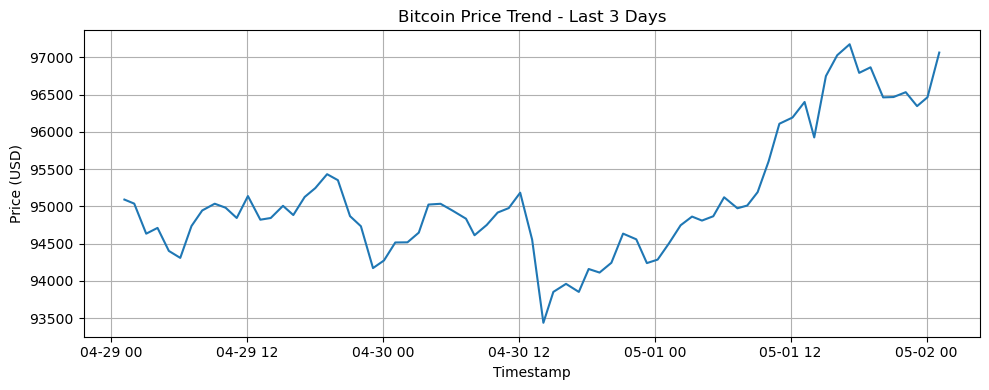

In [12]:
# Install required libraries
!pip install -q requests pandas matplotlib

# Imports
import os
import requests
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# Create directory structure
Path("data/raw").mkdir(parents=True, exist_ok=True)
Path("data/processed").mkdir(parents=True, exist_ok=True)
Path("results").mkdir(exist_ok=True)

# Utility function
def fetch_bitcoin_data(vs_currency="usd", days=3):
    url = "https://api.coingecko.com/api/v3/coins/bitcoin/market_chart"
    headers = {
        "User-Agent": "Mozilla/5.0"
    }
    params = {
        "vs_currency": vs_currency,
        "days": days
    }
    response = requests.get(url, params=params, headers=headers)

    if response.status_code == 200:
        data = response.json()
        prices = pd.DataFrame(data["prices"], columns=["timestamp", "price"])
        prices["timestamp"] = pd.to_datetime(prices["timestamp"], unit="ms")
        return prices
    else:
        print("Response content:", response.text)
        raise Exception(f"API Error: {response.status_code}")

# Fetch data
df = fetch_bitcoin_data(days=3)
print("Sample data:")
print(df.head())

# Save to CSV
csv_path = "data/raw/bitcoin_prices.csv"
df.to_csv(csv_path, index=False)
print(f"\nData saved to: {csv_path}")

# Plot
plt.figure(figsize=(10, 4))
plt.plot(df["timestamp"], df["price"])
plt.title("Bitcoin Price Trend - Last 3 Days")
plt.xlabel("Timestamp")
plt.ylabel("Price (USD)")
plt.grid(True)
plt.tight_layout()
plt.savefig("results/bitcoin_price_plot.png")
plt.show()


Sample data:
                timestamp         price
0 2025-04-29 01:09:19.570  95092.155934
1 2025-04-29 02:01:26.787  95037.684270
2 2025-04-29 03:04:53.530  94634.347753
3 2025-04-29 04:04:55.231  94711.855826
4 2025-04-29 05:04:53.801  94402.847589

Data saved to: data/raw/bitcoin_prices.csv


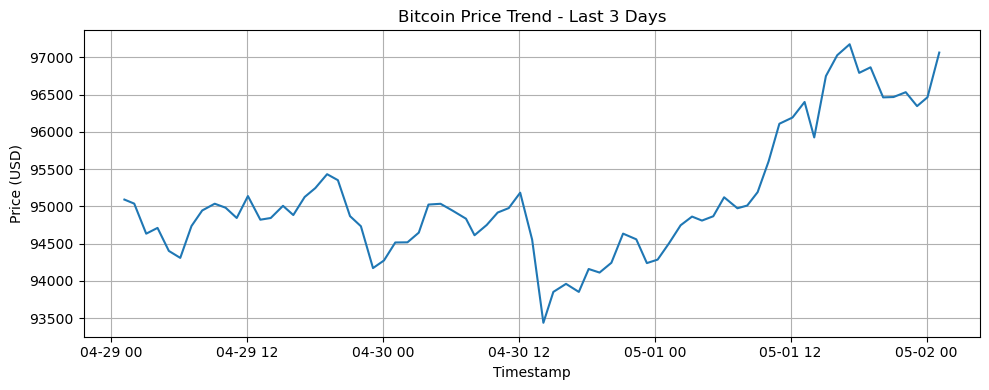

In [12]:
# Install required libraries
!pip install -q requests pandas matplotlib

# Imports
import os
import requests
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# Create directory structure
Path("data/raw").mkdir(parents=True, exist_ok=True)
Path("data/processed").mkdir(parents=True, exist_ok=True)
Path("results").mkdir(exist_ok=True)

# Utility function
def fetch_bitcoin_data(vs_currency="usd", days=3):
    url = "https://api.coingecko.com/api/v3/coins/bitcoin/market_chart"
    headers = {
        "User-Agent": "Mozilla/5.0"
    }
    params = {
        "vs_currency": vs_currency,
        "days": days
    }
    response = requests.get(url, params=params, headers=headers)

    if response.status_code == 200:
        data = response.json()
        prices = pd.DataFrame(data["prices"], columns=["timestamp", "price"])
        prices["timestamp"] = pd.to_datetime(prices["timestamp"], unit="ms")
        return prices
    else:
        print("Response content:", response.text)
        raise Exception(f"API Error: {response.status_code}")

# Fetch data
df = fetch_bitcoin_data(days=3)
print("Sample data:")
print(df.head())

# Save to CSV
csv_path = "data/raw/bitcoin_prices.csv"
df.to_csv(csv_path, index=False)
print(f"\nData saved to: {csv_path}")

# Plot
plt.figure(figsize=(10, 4))
plt.plot(df["timestamp"], df["price"])
plt.title("Bitcoin Price Trend - Last 3 Days")
plt.xlabel("Timestamp")
plt.ylabel("Price (USD)")
plt.grid(True)
plt.tight_layout()
plt.savefig("results/bitcoin_price_plot.png")
plt.show()


In [ ]:
!pip install pandas requests
!pip install dvc[gs]  # [gs] includes support for Google Drive remote if needed
